<a href="https://colab.research.google.com/github/FrancisDLopez/ml-prediccion-churn-cx/blob/main/notebooks/02_modelo_churn_nps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entrenando el modelo predictivo...

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.92      0.67      0.77       791
           1       0.38      0.78      0.51       209

    accuracy                           0.69      1000
   macro avg       0.65      0.72      0.64      1000
weighted avg       0.81      0.69      0.72      1000

AUC-ROC Score: 0.7441



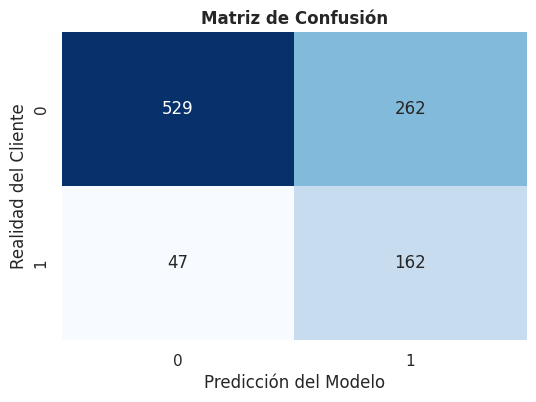

/tmp/ipykernel_918/3837872321.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


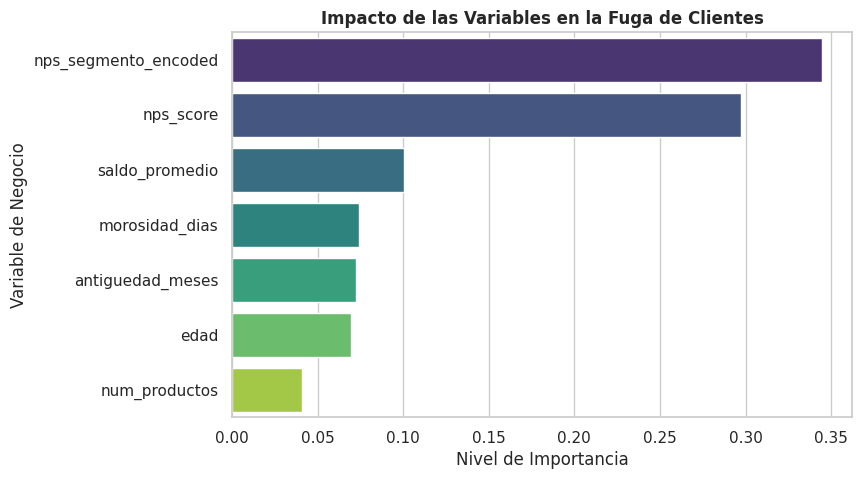

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Cargar los datos desde tu GitHub
url = 'https://raw.githubusercontent.com/FrancisDLopez/ml-prediccion-churn-cx/main/data/raw/dataset_churn_nps.csv'
df = pd.read_csv(url)

# 2. Preprocesamiento de Datos (Feature Engineering)
# Convertimos la variable de texto 'nps_segmento' en números para que el modelo la entienda
le = LabelEncoder()
df['nps_segmento_encoded'] = le.fit_transform(df['nps_segmento'])

# Definimos nuestras variables predictoras (X) y lo que queremos predecir (y)
X = df.drop(['cliente_id', 'churn', 'nps_segmento'], axis=1)
y = df['churn']

# Dividimos los datos: 80% para entrenar el modelo, 20% para ponerlo a prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenamiento del Modelo (Random Forest)
print("Entrenando el modelo predictivo...\n")
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# 4. Predicciones y Evaluación del Modelo
y_pred = modelo_rf.predict(X_test)
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}\n")

# 5. Visualización: Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')
plt.show()

# 6. Visualización: Importancia de las Variables
importancias = modelo_rf.feature_importances_
variables = X.columns
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Impacto de las Variables en la Fuga de Clientes', fontweight='bold')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable de Negocio')
plt.show()